## 🛠 Exercises

1. Build and fit a model using the same data we have here but with the MobileNetV2 architecture feature extraction ([`mobilenet_v2_100_224/feature_vector`](https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/4)) from TensorFlow Hub, how does it perform compared to our other models?
2. Name 3 different image classification models on TensorFlow Hub that we haven't used.
3. Build a model to classify images of two different things you've taken photos of.
  * You can use any feature extraction layer from TensorFlow Hub you like for this.
  * You should aim to have at least 10 images of each class, for example to build a fridge versus oven classifier, you'll want 10 images of fridges and 10 images of ovens.
4. What is the current best performing model on ImageNet?
  * Hint: you might want to check [sotabench.com](https://www.sotabench.com) for this.

## Import the right modules for tensorflow.keras

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
print(tf.__version__) # find the version number (should be 2.x+)
print(tf.config.list_physical_devices('GPU'))

version_fn = getattr(tf.keras, "version", None)
if version_fn and version_fn().startswith("3."):
    import tf_keras as keras
else:
    keras = tf.keras

2025-05-14 09:15:50.510386: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747224950.521620   14296 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747224950.524982   14296 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747224950.533507   14296 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747224950.533518   14296 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747224950.533519   14296 computation_placer.cc:177] computation placer alr

2.19.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load my own dataset: porous templates

### 1. Import and inspect data

In [2]:
import os

# Set images directory:
dir_images = "AAO_images/"

# Walk through the images directory and list number of files:
for dirpath, dirnames, filenames in os.walk(dir_images):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'AAO_images/'.
There are 4 directories and 0 images in 'AAO_images/test'.
There are 0 directories and 88 images in 'AAO_images/test/r4a7_PmenorIgual30'.
There are 0 directories and 65 images in 'AAO_images/test/r12a15_Pmayor40'.
There are 0 directories and 39 images in 'AAO_images/test/r4a7_Pmayor30'.
There are 0 directories and 65 images in 'AAO_images/test/r12a15_PmenorIgual40'.
There are 4 directories and 0 images in 'AAO_images/train'.
There are 0 directories and 354 images in 'AAO_images/train/r4a7_PmenorIgual30'.
There are 0 directories and 256 images in 'AAO_images/train/r12a15_Pmayor40'.
There are 0 directories and 159 images in 'AAO_images/train/r4a7_Pmayor30'.
There are 0 directories and 254 images in 'AAO_images/train/r12a15_PmenorIgual40'.


In [3]:
# Get the class names (programmatically, this is much more helpful with a longer list of classes)
import pathlib
import numpy as np

data_dir = pathlib.Path(dir_images+'train/') # turn our training path into a Python path
class_names = np.array(sorted([item.name for item in data_dir.glob('*')])) # created a list of class_names from the subdirectories
print(class_names)

['r12a15_Pmayor40' 'r12a15_PmenorIgual40' 'r4a7_Pmayor30'
 'r4a7_PmenorIgual30']


In [4]:
# View an image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  # Setup target directory (we'll view images from here)
  target_folder = target_dir+target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img,cmap='gray')
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}") # show the shape of the image

  return img

Image shape: (256, 256)


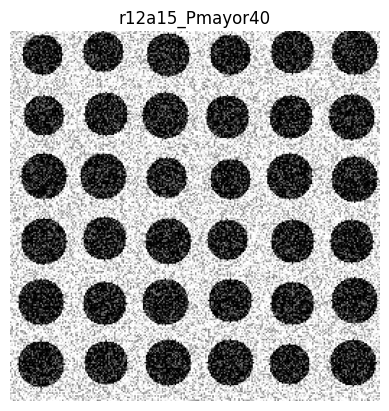

In [5]:
# View a random image from the training dataset
img = view_random_image(target_dir=dir_images+'train/',
                        target_class="r12a15_Pmayor40")

### 2. Preprocess the data

In [6]:
# Setup the train and test directories
train_dir = dir_images+"train/"
test_dir = dir_images+"test/"

# Create data inputs
IMG_SIZE = (256, 256) # define image size
train_data = tf.keras.preprocessing.image_dataset_from_directory(directory=train_dir,
                                                                 image_size=IMG_SIZE,
                                                                 color_mode='rgb', # Convert to 3 channels
                                                                 label_mode="categorical", # what type are the labels?
                                                                 batch_size=32) # batch_size is 32 by default, this is generally a good number
test_data = tf.keras.preprocessing.image_dataset_from_directory(directory=test_dir,
                                                                image_size=IMG_SIZE,
                                                                color_mode='rgb', # Convert to 3 channels
                                                                label_mode="categorical")

Found 1023 files belonging to 4 classes.


I0000 00:00:1747224952.336693   14296 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1216 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 257 files belonging to 4 classes.


In [7]:
# Normalize data:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_data_norm = train_data.map(lambda x, y: (normalization_layer(x), y))
test_data_norm = test_data.map(lambda x, y: (normalization_layer(x), y))

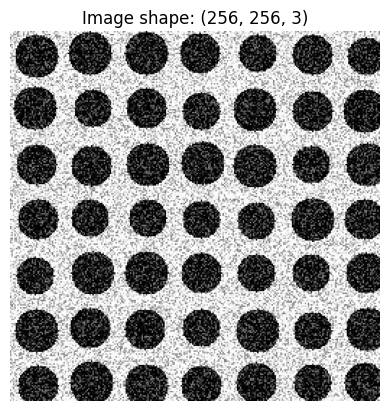

In [8]:
# See an example batch of data
for images, labels in train_data_norm.take(1):
    plt.imshow(images[0])
    plt.axis("off");
    plt.title(f"Image shape: {images[0].shape}") # show the shape of the image
    plt.show()
    break

### Create, fit and evaluate a model (baseline)

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

# Create our model
model_1 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(256, 256, 3)),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(len(class_names), activation='softmax') # changed to have 10 neurons (same as number of classes) and 'softmax' activation
])

# Compile the model
model_1.compile(loss="categorical_crossentropy", # changed to categorical_crossentropy
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])
model_1.summary()

/home/meneses/miniconda3/envs/py12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 252, 252, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 126, 126, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 122, 122, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 37210)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       148,844 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,854 (593.18 KB)

 Trainable params: 151,854 (593.18 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Fit the model
history_1 = model_1.fit(train_data_norm,
                        # steps_per_epoch=len(train_data),
                        validation_data=test_data_norm,
                        # validation_steps=len(test_data),
                        epochs=20)

Epoch 1/20


I0000 00:00:1747224954.383527   14445 service.cc:152] XLA service 0x7a09f4004990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747224954.383574   14445 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1747224954.691473   14445 cuda_dnn.cc:529] Loaded cuDNN version 90300


 7/32 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3555 - loss: 1.8003

I0000 00:00:1747224959.337949   14445 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 206ms/step - accuracy: 0.3696 - loss: 1.5081 - val_accuracy: 0.7276 - val_loss: 0.6546
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8373 - loss: 0.4016 - val_accuracy: 0.9183 - val_loss: 0.2165
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9711 - loss: 0.1078 - val_accuracy: 0.9377 - val_loss: 0.1510
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9826 - loss: 0.0590 - val_accuracy: 0.9611 - val_loss: 0.1107
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9858 - loss: 0.0487 - val_accuracy: 0.8911 - val_loss: 0.2910
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9606 - loss: 0.0812 - val_accuracy: 0.9105 - val_loss: 0.2084
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9637 - loss: 0.0805 - val_accuracy: 0.9455 - val_loss: 0.1549
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9941 - loss: 0.0211 - val_accuracy: 0.9494 - val_loss: 

In [12]:
# Plot the validation and training data separately
def plot_acc_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """ 
  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

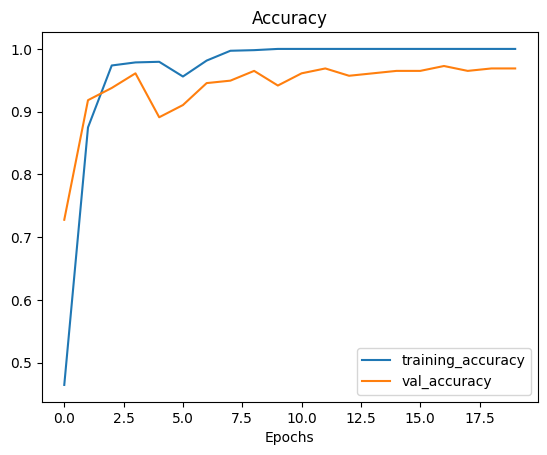

In [13]:
# Check out the model's loss curves on the 10 classes of data (note: this function comes from above in the notebook)
plot_acc_curves(history_1)

## Use transfer learning and fit a pre-trained model

In [14]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
import tensorflow_hub as hub

def create_model(model_url, num_classes=10):
  """Takes a TensorFlow Hub URL and creates a Keras Sequential model with it.
  
  Args:
    model_url (str): A TensorFlow Hub feature extraction URL.
    num_classes (int): Number of output neurons in output layer,
      should be equal to number of target classes, default 10.

  Returns:
    An uncompiled Keras Sequential model with model_url as feature
    extractor layer and Dense output layer with num_classes outputs.
  """
  # Download the pretrained model and save it as a Keras layer
  feature_extractor_layer = hub.KerasLayer(model_url,
                                           trainable=False, # freeze the underlying patterns
                                           name='feature_extraction_layer',
                                           input_shape=(256,256)+(3,)) # define the input image shape
  #hub_layer_wrapper = tf.keras.layers.Lambda(lambda x: feature_extractor_layer(x))
  # Create our own model
  model = keras.Sequential([
    feature_extractor_layer, # use the feature extraction layer as the base
    keras.layers.Dense(num_classes, activation='softmax', name='output_layer') # create our own output layer      
  ])

  return model

In [15]:
# Define the input shape for grayscale images
# input_shape = (256, 256, 3) # Replace height and width with your image dimensions

# Load the EfficientNetB0 model without the top layer
# base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)

In [16]:
efficientnet_url = "https://tfhub.dev/google/imagenet/efficientnet_v2_imagenet1k_b0/feature_vector/2"
B0_model = create_model(efficientnet_url, num_classes=len(class_names))

In [17]:
# Compile
B0_model.compile(loss='categorical_crossentropy',
                 optimizer=keras.optimizers.Adam(),
                 metrics=['accuracy'])
B0_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extraction_layer (  (None, 1280)              5919312   
 KerasLayer)                                                     
                                                                 
 output_layer (Dense)        (None, 4)                 5124      
                                                                 
Total params: 5924436 (22.60 MB)
Trainable params: 5124 (20.02 KB)
Non-trainable params: 5919312 (22.58 MB)
_________________________________________________________________


In [18]:
# Fit the model
B0_history = B0_model.fit(train_data_norm,
                          epochs=20,
                          steps_per_epoch=len(train_data_norm),
                          validation_data=test_data_norm,
                          validation_steps=len(test_data_norm),
                          )

Epoch 1/20
32/32 [==============================] - 7s 86ms/step - loss: 0.8545 - accuracy: 0.6774 - val_loss: 0.5143 - val_accuracy: 0.9144
Epoch 2/20
32/32 [==============================] - 2s 50ms/step - loss: 0.4112 - accuracy: 0.8964 - val_loss: 0.3233 - val_accuracy: 0.9144
Epoch 3/20
32/32 [==============================] - 2s 49ms/step - loss: 0.2966 - accuracy: 0.9179 - val_loss: 0.2563 - val_accuracy: 0.9377
Epoch 4/20
32/32 [==============================] - 2s 49ms/step - loss: 0.2464 - accuracy: 0.9257 - val_loss: 0.2173 - val_accuracy: 0.9455
Epoch 5/20
32/32 [==============================] - 2s 49ms/step - loss: 0.2182 - accuracy: 0.9316 - val_loss: 0.1949 - val_accuracy: 0.9494
Epoch 6/20
32/32 [==============================] - 2s 49ms/step - loss: 0.1956 - accuracy: 0.9462 - val_loss: 0.1765 - val_accuracy: 0.9572
Epoch 7/20
32/32 [==============================] - 2s 49ms/step - loss: 0.1797 - accuracy: 0.9511 - val_loss: 0.1616 - val_accuracy: 0.9611
Epoch 8/20
32

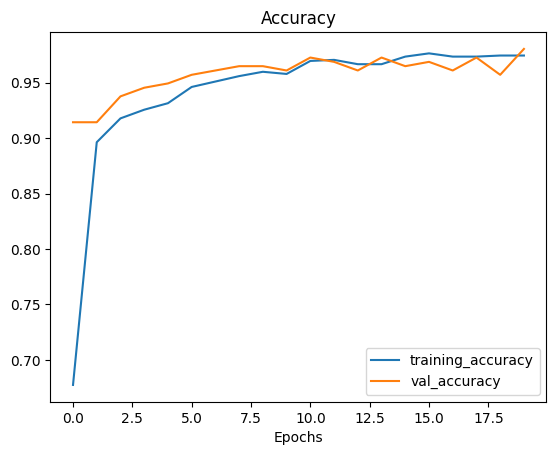

In [19]:
plot_acc_curves(B0_history)

In [20]:
# Evaluate on the test data
loss, acc = model_1.evaluate(test_data_norm)
print(f'Baseline model, Accuracy on test dataset: {acc*100:.2f}%')

loss, acc = B0_model.evaluate(test_data_norm)
print(f'Transferred model, Accuracy on test dataset: {acc*100:.2f}%')

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9704 - loss: 0.0728
Baseline model, Accuracy on test dataset: 96.89%
9/9 [==============================] - 0s 34ms/step - loss: 0.0936 - accuracy: 0.9805
Transferred model, Accuracy on test dataset: 98.05%


## 📖 Extra-curriculum

* Read through the [TensorFlow Transfer Learning Guide](https://www.tensorflow.org/tutorials/images/transfer_learning) and define the main two types of transfer learning in your own words.
* Go through the [Transfer Learning with TensorFlow Hub tutorial](https://www.tensorflow.org/tutorials/images/transfer_learning_with_hub) on the TensorFlow website and rewrite all of the code yourself into a new Google Colab notebook making comments about what each step does along the way.
* We haven't covered fine-tuning with TensorFlow Hub in this notebook, but if you'd like to know more, go through the [fine-tuning a TensorFlow Hub model tutorial](https://www.tensorflow.org/hub/tf2_saved_model#fine-tuning) on the TensorFlow homepage.How to fine-tune a tensorflow hub model:  
* Look into [experiment tracking with Weights & Biases](https://www.wandb.com/experiment-tracking), how could you integrate it with our existing TensorBoard logs?